# Detailed Exploratory Data Analysis (EDA) on Soil RGB and SOC
This notebook contains an in-depth exploratory data analysis of the relationships between soil color features (Red, Green, Blue) and Soil Organic Carbon (SOC) levels. 

The analysis includes outlier detection, feature engineering (brightness), high-density plotting (hexbins), and a masked correlation matrix.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visual style for larger plots
sns.set_theme(style="whitegrid", context="talk")
%matplotlib inline

## 1. Data Loading

In [2]:
file_path = 'soil_RGB_SOC_data.csv'
df = pd.read_csv(file_path)
df.head()

,R,G,B,SOC
0,0.341532,0.293612,0.244217,3.331952
1,0.494881,0.449789,0.323566,2.400840
2,0.274489,0.253412,0.188667,3.627119
3,0.194135,0.173961,0.132181,4.020393
4,0.661541,0.564222,0.467340,1.766361


## 2. Advanced Summary Statistics & Missing Values

In [3]:
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print("\nMissing Values:")
print(df.isnull().sum())
print("\nSummary Statistics with Percentiles:")
display(df.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

Total Records: 50000
Total Features: 4

Missing Values:
R      0
G      0
B      0
SOC    0
dtype: int64

Summary Statistics with Percentiles:


,R,G,B,SOC
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,0.473869,0.414618,0.321296,2.582143
std,0.187503,0.165609,0.129623,1.021720
min,0.150024,0.120779,0.085681,0.050000
5%,0.183121,0.159800,0.123177,0.956319
25%,0.311574,0.271563,0.209407,1.755878
50%,0.473655,0.412986,0.318691,2.587547
75%,0.635689,0.555234,0.428996,3.417366
95%,0.767491,0.674683,0.528258,4.185592
max,0.799989,0.758642,0.639886,5.000000


## 3. Distributions and Outlier Detection
We use histograms (top) to see the spread and boxplots (bottom) to identify statistical outliers.

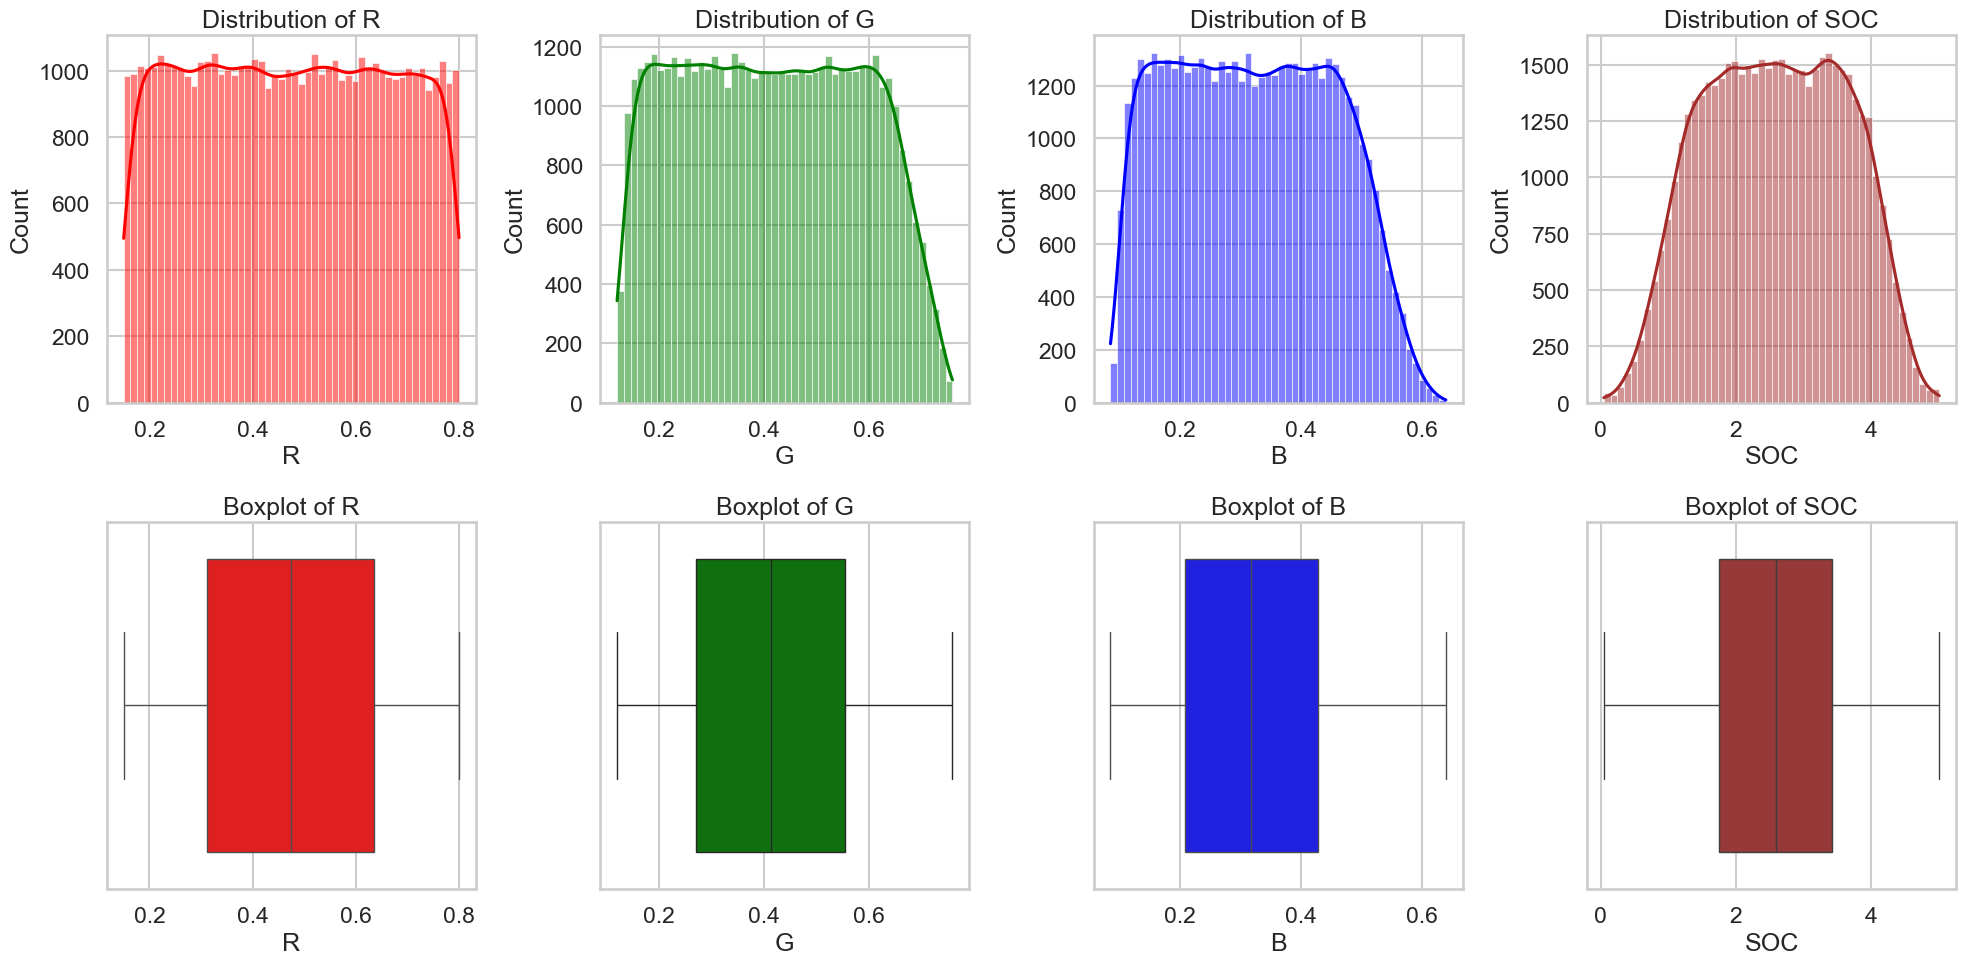

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
features = ['R', 'G', 'B', 'SOC']
colors = ['red', 'green', 'blue', 'brown']

for i, (col, color) in enumerate(zip(features, colors)):
    # Histograms with KDE
    sns.histplot(df[col], kde=True, bins=50, color=color, ax=axes[0, i])
    axes[0, i].set_title(f'Distribution of {col}')
    
    # Boxplots for outliers
    sns.boxplot(x=df[col], color=color, ax=axes[1, i])
    axes[1, i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

## 4. Feature Engineering: Brightness
We can derive a `Brightness` feature by averaging the R, G, and B components. Since darker soils generally have higher SOC, this combined metric should strongly correlate negatively with SOC.

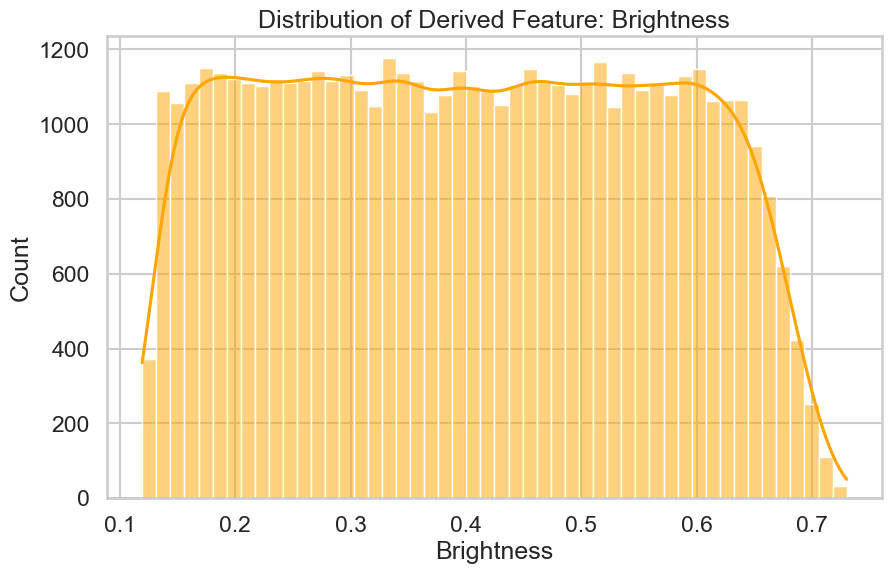

In [5]:
df['Brightness'] = (df['R'] + df['G'] + df['B']) / 3.0

plt.figure(figsize=(10, 6))
sns.histplot(df['Brightness'], kde=True, bins=50, color='orange')
plt.title('Distribution of Derived Feature: Brightness')
plt.show()

## 5. High-Density Scatter Analysis (Hexbin plots)
When dealing with 50,000 points, standard scatter plots suffer from severe overplotting. Hexbin plots show us the *density* of points.

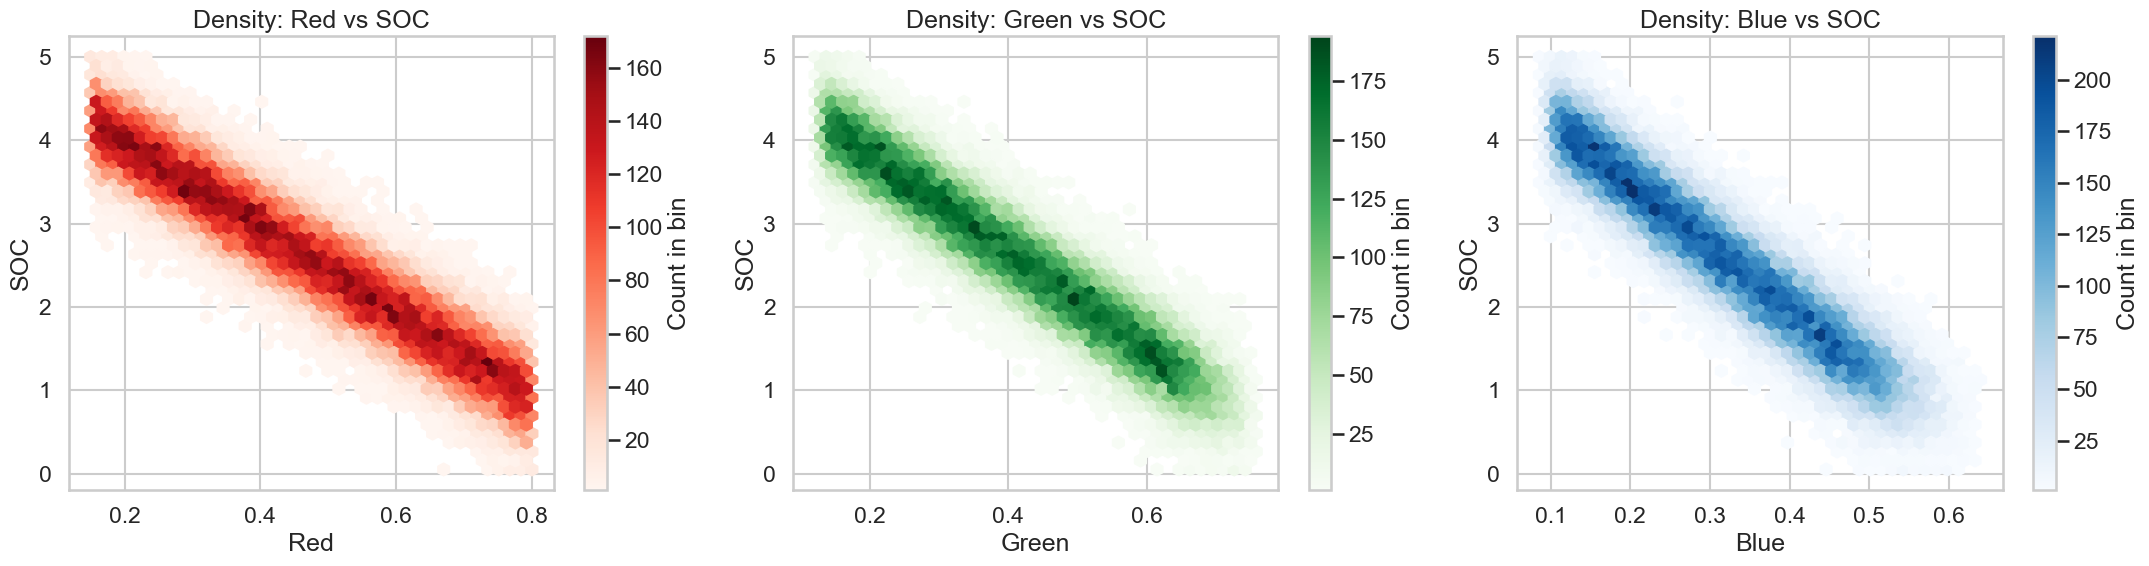

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

hb1 = axes[0].hexbin(df['R'], df['SOC'], gridsize=40, cmap='Reds', mincnt=1)
axes[0].set_xlabel('Red')
axes[0].set_ylabel('SOC')
axes[0].set_title('Density: Red vs SOC')
fig.colorbar(hb1, ax=axes[0], label='Count in bin')

hb2 = axes[1].hexbin(df['G'], df['SOC'], gridsize=40, cmap='Greens', mincnt=1)
axes[1].set_xlabel('Green')
axes[1].set_ylabel('SOC')
axes[1].set_title('Density: Green vs SOC')
fig.colorbar(hb2, ax=axes[1], label='Count in bin')

hb3 = axes[2].hexbin(df['B'], df['SOC'], gridsize=40, cmap='Blues', mincnt=1)
axes[2].set_xlabel('Blue')
axes[2].set_ylabel('SOC')
axes[2].set_title('Density: Blue vs SOC')
fig.colorbar(hb3, ax=axes[2], label='Count in bin')

plt.tight_layout()
plt.show()

## 6. Brightness vs SOC Density Plot

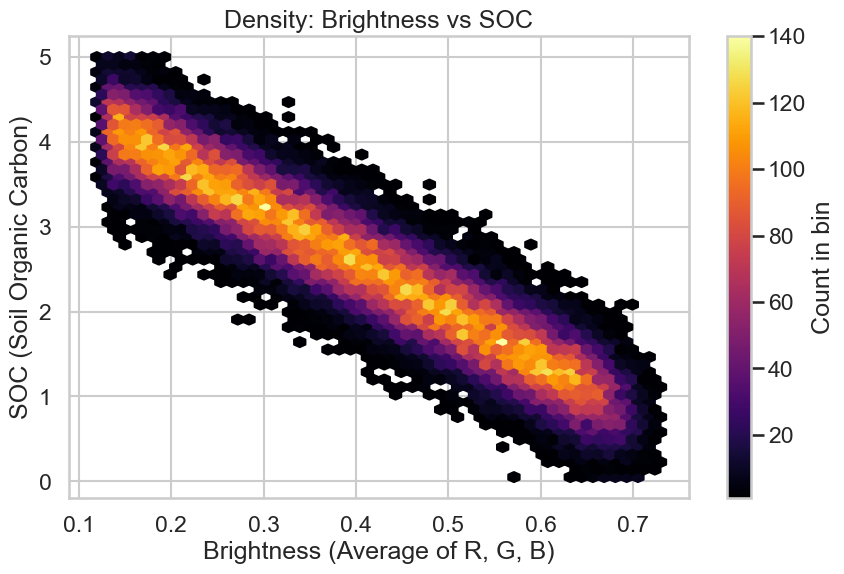

In [7]:
plt.figure(figsize=(10, 6))
plt.hexbin(df['Brightness'], df['SOC'], gridsize=50, cmap='inferno', mincnt=1)
plt.colorbar(label='Count in bin')
plt.xlabel('Brightness (Average of R, G, B)')
plt.ylabel('SOC (Soil Organic Carbon)')
plt.title('Density: Brightness vs SOC')
plt.show()

## 7. Detailed Correlation Matrix
We use a lower-triangle masked heatmap for a cleaner presentation.

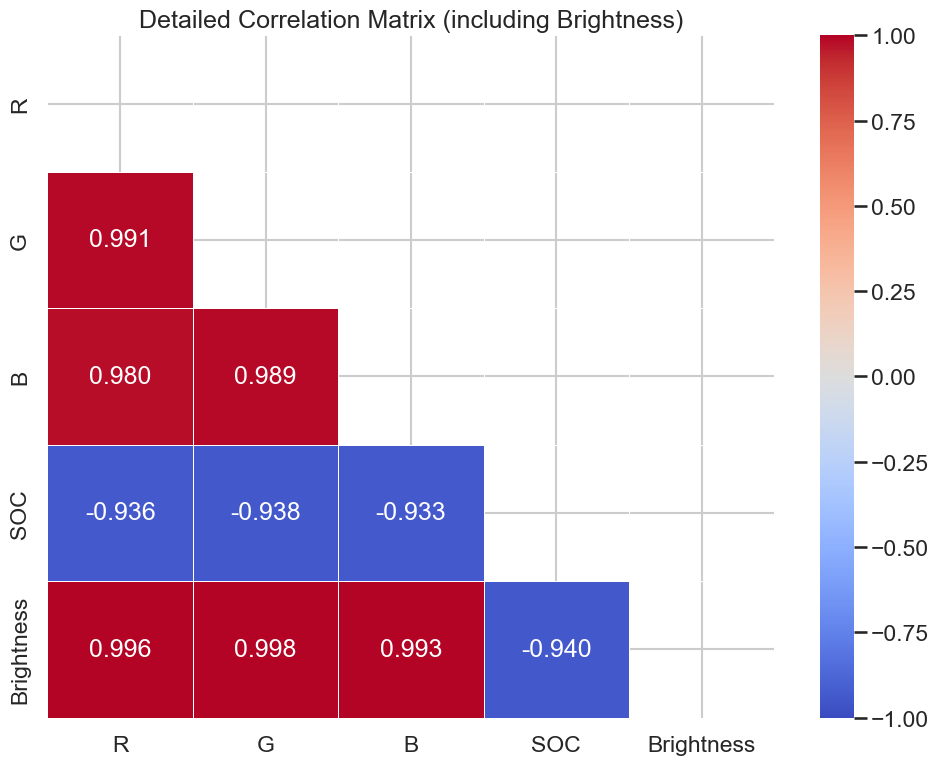

In [8]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
# Create mask for upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f", linewidths=.5)
plt.title('Detailed Correlation Matrix (including Brightness)')
plt.tight_layout()
plt.show()